In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

from scipy.stats import pearsonr

pd.set_option('display.float_format', '{:,.2f}'.format)

# IMPORTATION AND CLEANING. 

In [2]:
df = pd.read_excel("Data for Case.xlsx", sheet_name="Export")

# Formulas!!!
# ___________________________________________

# net sales = gross sales - (returns + rebates)

# Gross margin % = (net sales + COGS)/net sales 

# Contrib margin = (net sales + COGS) + (Comissions + Freight)

# Contrib. Margin/Net %  = (Contrib margin/net sales) * 100 

# Net/PC = Net sales/Volume(PC)

# ___________________________________________

In [3]:
df.sort_values(by = "Contrib. Margin/Net %", inplace=True)

In [4]:
# Cleaning. 

df.columns = df.columns.str.rstrip()
df.columns = df.columns.str.lstrip()

df[["Returns", "Rebates", "Commissions", "Freight"]] = df[["Returns", "Rebates", "Commissions", "Freight"]].fillna(value = 0)

In [5]:
# Defining our new features to see if the formulas are correct. 

df["Our Net Sales"] = df["Gross Sales"] + (df["Returns"] + df["Rebates"])
df["Our Gross Margin %"] = (df["Net Sales"] + df["COGS"])/df["Net Sales"] 
df["Our Contrib Margin"] = df["Net Sales"] + df["COGS"] + df["Commissions"] + df["Freight"]
df["Our Contrib Margin/Net %"] = (df["Contrib. Margin"]/df["Net Sales"])
df["Our Net/Pc"] = df["Net Sales"]/df["Volume (Pc)"]

In [ ]:
# Mothballed expoloratory code. 

# print(pearsonr(df["Our Net Sales"] , df["Net Sales"]))
# print(pearsonr(df["Our Gross Margin %"], df["Gross Margin %"]))
# print(pearsonr(df["Our Contrib Margin"], df["Contrib. Margin"]))
# print(pearsonr(df["Our Contrib Margin/Net %"] , df["Contrib. Margin/Net %"]))
# print(pearsonr(df["Our Net/Pc"], df["Net/Pc"]))


# plt.scatter(x = df["Our Contrib Margin"], y = df["Contrib. Margin"])
# plt.ticklabel_format(style='plain', useOffset=False, axis='both') # 'both' affects x and y axes
# plt.xlabel("Our Contrib. Margin")
# plt.ylabel("Actual Contrib. Margin")
# plt.savefig("Contrib_Margin.png")
# plt.show()

In [6]:
# Getting rid of the weird customers. 

df = df[df["Customer"].isin(["Customer 19", "Customer 63"]) == False]

# Getting rid of our defined columns
df.drop(labels = ["Our Net Sales", "Our Gross Margin %", "Our Contrib Margin", 
                       "Our Contrib Margin/Net %", "Our Net/Pc"], axis= 1, inplace=True)

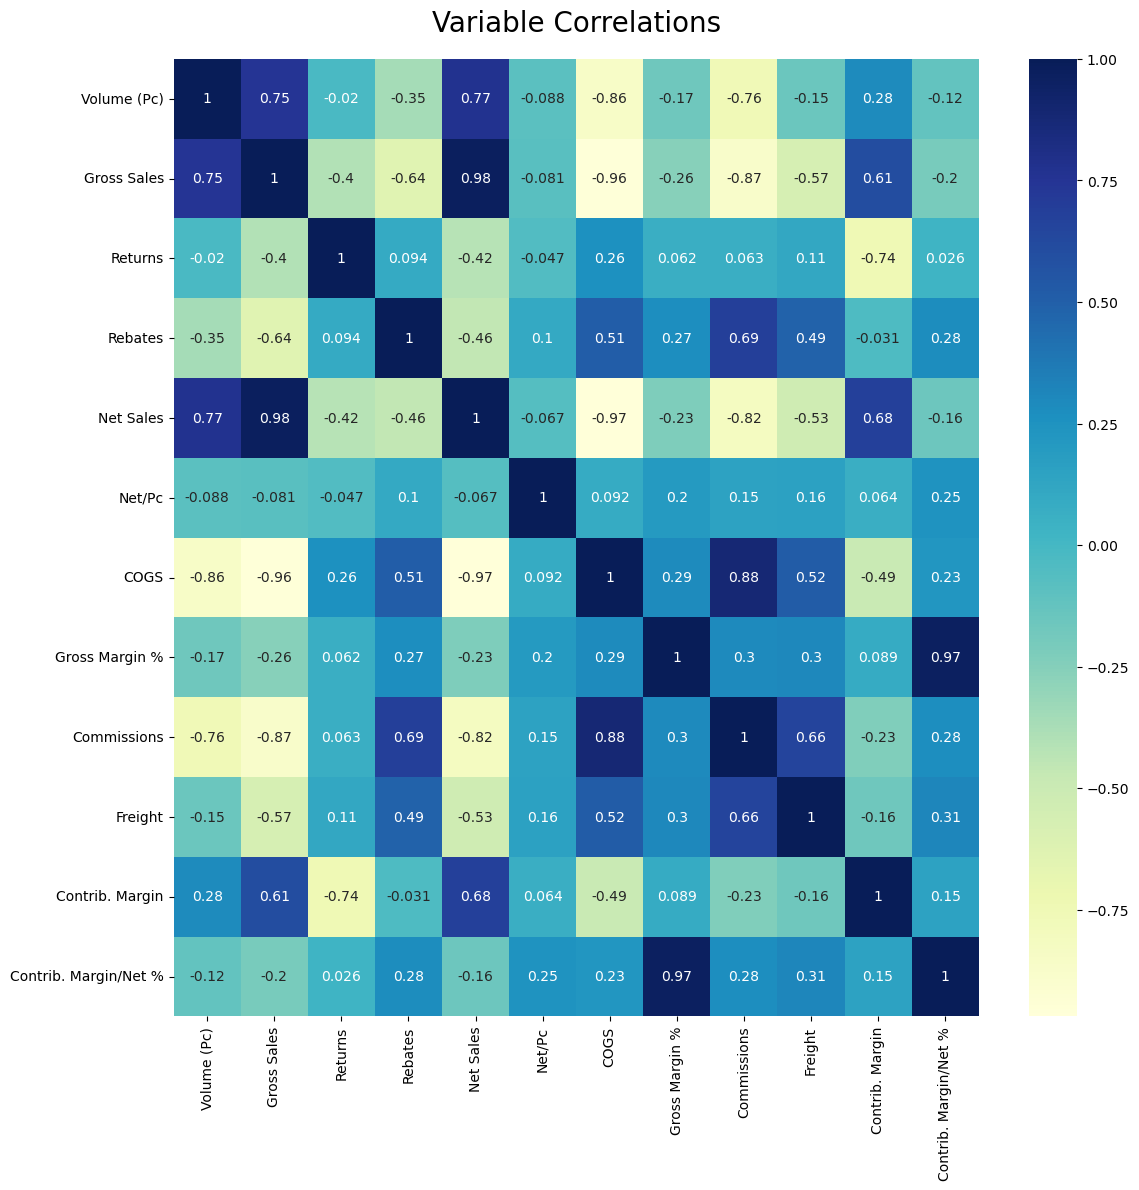

In [7]:
# Making SNS Heatmap (just in case)

correlation_matrix = df.corr(numeric_only=True)

fig = plt.figure(figsize=(12, 12))
sns.heatmap(correlation_matrix, cmap="YlGnBu", annot=True)
plt.title(label="Variable Correlations", fontsize=20, y=1.02)
plt.tight_layout() 
plt.savefig("heatmap.png")
plt.show()

# CUSTOMER SEGMENTATION

In [9]:
# Getting only the numeric columns for the groupbys 
# later in the notebook. 
numeric_cols_list = [key for key in df.keys() if key not in ["Customer", "Segment"]]

## Look at profitable versus unprofitable

In [10]:
new_df = df.copy(deep=True)
new_df["Profitability"] = None
new_df.loc[df["Contrib. Margin/Net %"] > 0, "Profitability"] = "Profitable"
new_df.loc[df["Contrib. Margin/Net %"] < 0, "Profitability"] = "Unprofitable"

new_df.groupby("Profitability")[numeric_cols_list].agg(["mean", "median"])

Volume (Pc)            Gross Sales               Returns         \
                     mean     median        mean     median       mean median   
Profitability                                                                   
Profitable     339,488.04  40,427.00  326,253.46  91,001.07  -2,374.49   0.00   
Unprofitable   640,496.38 184,581.00  965,572.92 223,210.86 -10,360.47 -88.71   

                  Rebates          Net Sales             ... Gross Margin %  \
                     mean  median       mean     median  ...           mean   
Profitability                                            ...                  
Profitable     -28,400.09 -606.80 295,478.88  87,803.42  ...           0.50   
Unprofitable  -335,116.25 -974.58 620,096.20 222,372.23  ...           0.02   

                     Commissions              Freight             \
              median        mean    median       mean     median   
Profitability                                                      
Profitable      0.52  -13,352.27 -4,339.27 -17,880.28  -7,023.81   
Unprofitable    0.06  -45,415.38 -9,438.77 -61,020.93 -25,893.12   

              Contrib. Margin            Contrib. Margin/Net %         
                         mean     median                  mean median  
Profitability                                                          
Profitable          81,633.19  30,069.35                  0.35   0.36  
Unprofitable       -75,339.55 -25,675.88                 -0.17  -0.08  

[2 rows x 24 columns]

In [11]:
# Least profitable customers (by percentage)
df.sort_values(by="Contrib. Margin/Net %", inplace=True)
df

,Customer,Segment,Volume (Pc),Gross Sales,Returns,Rebates,Net Sales,Net/Pc,COGS,Gross Margin %,Commissions,Freight,Contrib. Margin,Contrib. Margin/Net %
159,Customer 299,Irrigation,"175,560.00","36,591.36",-259.56,-9.60,"36,322.20",0.21,"-59,872.06",-0.65,"-1,816.59","-2,374.23","-27,984.00",-0.77
78,Customer 218,Irrigation,"44,532.00","66,713.83",0.00,"-8,863.17","57,850.66",1.30,"-71,897.74",-0.24,"-2,630.62","-8,998.18","-25,675.88",-0.44
186,Customer 133,Plumbing,"175,756.00","104,177.39",0.00,0.00,"104,177.39",0.59,"-122,064.54",-0.17,"-5,208.95","-22,364.84","-45,460.94",-0.44
206,Customer 27,Plumbing,"836,189.00","753,841.59","-34,196.53","-26,739.99","692,905.07",0.83,"-812,185.99",-0.17,"-36,013.16","-104,814.53","-260,108.61",-0.38
118,Customer 258,Irrigation,"89,033.00","46,518.57",0.00,-17.35,"46,501.22",0.52,"-50,576.85",-0.09,"-2,325.36","-8,659.60","-15,060.59",-0.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,Customer 283,Irrigation,"1,702.00","40,493.20",0.00,0.00,"40,493.20",23.79,"-7,561.13",0.81,0.00,"-3,184.22","29,747.85",0.73
54,Customer 193,Irrigation,"26,410.00","69,001.46",0.00,0.00,"69,001.46",2.61,"-17,980.05",0.74,0.00,0.00,"51,021.41",0.74
79,Customer 219,Irrigation,"10,096.00","57,541.26",0.00,0.00,"57,541.26",5.70,"-13,973.38",0.76,0.00,-409.12,"43,158.76",0.75
73,Customer 213,Irrigation,"6,999.00","61,216.09","-1,439.23",-600.36,"59,176.50",8.45,"-9,835.98",0.83,"-2,948.76",-538.62,"45,853.14",0.77


In [12]:
# Least profitable customers (Absolute)
df.sort_values(by="Contrib. Margin", inplace=True)
df

,Customer,Segment,Volume (Pc),Gross Sales,Returns,Rebates,Net Sales,Net/Pc,COGS,Gross Margin %,Commissions,Freight,Contrib. Margin,Contrib. Margin/Net %
171,Customer 12,Plumbing,"2,003,547.00","4,839,198.77","-3,238.40","-3,142,456.02","1,693,504.35",0.85,"-1,626,780.27",0.04,"-251,900.27","-163,825.09","-364,814.99",-0.22
286,Customer 10,Retail,"2,084,587.00","2,433,070.10","-13,669.52","-249,114.27","2,170,286.31",1.04,"-2,222,904.23",-0.02,"-117,209.67","-116,355.57","-286,917.48",-0.13
206,Customer 27,Plumbing,"836,189.00","753,841.59","-34,196.53","-26,739.99","692,905.07",0.83,"-812,185.99",-0.17,"-36,013.16","-104,814.53","-260,108.61",-0.38
194,Customer 16,Plumbing,"1,111,561.00","2,181,183.25","-21,296.76","-1,002,601.60","1,157,284.89",1.04,"-1,037,387.32",0.10,"-116,715.99","-180,810.10","-197,019.03",-0.17
253,Customer 7,Plumbing,"3,140,765.00","4,423,839.63","-5,100.31","-1,648,779.50","2,769,959.82",0.88,"-2,615,110.03",0.06,"-121,432.91","-167,879.46","-135,143.03",-0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,Customer 3,Plumbing,"4,046,988.00","5,860,152.29","-13,565.76","-207,959.50","5,638,627.03",1.39,"-4,022,214.65",0.29,"-304,614.51","-553,745.45","748,104.82",0.13
220,Customer 4,Plumbing,"10,393,606.00","4,287,764.43",-255.80,"-151,865.94","4,135,642.69",0.40,"-3,010,458.39",0.27,"-210,112.09",-702.29,"914,369.92",0.22
231,Customer 5,Plumbing,"4,244,356.00","4,319,860.09","-8,893.96","-707,155.95","3,603,810.18",0.85,"-2,131,222.64",0.41,"-153,313.38","-294,600.77","1,000,531.10",0.28
160,Customer 1,Plumbing,"39,696,218.00","11,199,413.47",-335.28,"-1,150,170.57","10,048,907.62",0.25,"-8,583,084.60",0.15,"-450,493.02","-4,020.32","1,011,257.14",0.10


## Segment by Customer

In [13]:
# Counts
# Irrigation: 160
# Plumbing: 126
# Retail: 13

df.groupby("Segment")[numeric_cols_list].agg(["mean", "median"])

Volume (Pc)            Gross Sales              Returns          \
                  mean     median        mean     median      mean  median   
Segment                                                                      
Irrigation   35,703.92  17,708.00   63,789.61  59,358.80   -422.59    0.00   
Plumbing    801,868.01 156,796.50  794,811.02 252,361.74 -6,537.52 -101.56   
Retail      246,838.15  67,141.00  316,720.14 144,513.14 -2,046.68  -84.78   

               Rebates            Net Sales             ... Gross Margin %  \
                  mean    median       mean     median  ...           mean   
Segment                                                 ...                  
Irrigation   -1,499.35   -143.55  61,867.67  57,438.58  ...           0.52   
Plumbing   -125,246.43 -3,305.15 663,027.07 239,749.76  ...           0.39   
Retail      -25,559.97 -1,317.75 289,113.49 135,890.12  ...           0.36   

                  Commissions               Freight             \
           median        mean     median       mean     median   
Segment                                                          
Irrigation   0.54   -3,141.25  -3,132.94  -5,411.75  -4,936.76   
Plumbing     0.42  -32,789.80 -11,892.38 -42,342.72 -18,986.43   
Retail       0.36  -15,282.05  -7,761.81 -20,967.98 -11,987.93   

           Contrib. Margin           Contrib. Margin/Net %         
                      mean    median                  mean median  
Segment                                                            
Irrigation       22,564.86 21,994.94                  0.37   0.39  
Plumbing        134,087.41 56,222.23                  0.24   0.26  
Retail            6,424.73 20,485.81                  0.20   0.17  

[3 rows x 24 columns]

## Making 3D charts

In [15]:
# Doing some feature engineering. Only transforming 
# Segment and the 3 numeric feautures we decided to care about. 

# The 3 features we care about. 
selected_columns = ["Volume (Pc)", "Contrib. Margin/Net %", "Net Sales"]

le_object = LabelEncoder()
le_object.fit(df["Segment"])
df["Segment"] = le_object.transform(df["Segment"])

mms_object = MinMaxScaler()
mms_object.fit(df[selected_columns])
df[selected_columns] = mms_object.transform(df[selected_columns])

In [ ]:
# For getting the breakpoint of profitability on
# Margin percentage, which is 0.5. This code is mothballed. 

# test_df = pd.DataFrame({"Volume (Pc)": [100000],
#                         "Contrib. Margin/Net %":[0.0], 
#                         "Net Sales": [100000]})

# test_df[test_df.keys()] = mms_object.transform(test_df[test_df.keys()])
# test_df

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d') #


# 3. Plot the data
scatter1 = ax.scatter(df["Volume (Pc)"], df["Net Sales"], df["Contrib. Margin/Net %"], 
           c=df["Segment"], marker='o', cmap="Set2_r", alpha=1.0, depthshade=False) 

ax.set_box_aspect(aspect=None, zoom=1.3)


scatter_legend = ax.legend(scatter1.legend_elements()[0], le_object.classes_, title="Segment", loc='upper left')

ax.add_artist(scatter_legend)

# 4. Set labels for the axes
ax.set_xlabel("Volume")
ax.set_ylabel("Net Sales")
ax.set_zlabel("Margin %")

#
# ax.set_zticks(np.arange(0, 1.1, 0.1))

# 5. Set title and display the plot
ax.set_title('3D Visualization')
ax.dist=1
ax.view_init(elev=0, azim=0) 
plt.savefig("margin_percentage.png")
# plt.show()

## Making the Rotation Video

In [ ]:
# https://www.google.com/search?q=Python+Axes3d+make+rotating+scatter+plot+mp4+video&sca_esv=9d6c1932d2d26a07&rlz=1C1UEAD_enUS1112US1112&sxsrf=ANbL-n7TvVFeh0DQSyG0tFaWkAtU4vXezw%3A1771183885532&ei=DR-SaeGaIMb_p84PraPa2AQ&ved=0ahUKEwih1dCSntySAxXG_8kDHa2RFksQ4dUDCBM&uact=5&oq=Python+Axes3d+make+rotating+scatter+plot+mp4+video&gs_lp=Egxnd3Mtd2l6LXNlcnAiMlB5dGhvbiBBeGVzM2QgbWFrZSByb3RhdGluZyBzY2F0dGVyIHBsb3QgbXA0IHZpZGVvMgUQIRigATIFECEYoAEyBRAhGKABMgUQIRigATIFECEYoAEyBRAhGKsCSMDOA1DXBliFzQNwBngAkAEAmAG8AaABuwuqAQQxMi4zuAEDyAEA-AEBmAIUoAKzC8ICChAAGLADGNYEGEeYAwCIBgGQBgiSBwQxNy4zoAf9SbIHBDExLjO4B6QLwgcGNy4xMi4xyAcYgAgA&sclient=gws-wiz-serp

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d') #


# 3. Plot the data
scatter1 = ax.scatter(df["Volume (Pc)"], df["Net Sales"], df["Contrib. Margin/Net %"], 
           c=df["Segment"], marker='o', cmap="Set2_r", alpha=1.0, depthshade=False) 

ax.set_box_aspect(aspect=None, zoom=1.0)


scatter_legend = ax.legend(scatter1.legend_elements()[0], le_object.classes_, title="Segment", loc='upper left')

ax.add_artist(scatter_legend)

# 4. Set labels for the axes
ax.set_xlabel("Volume")
ax.set_ylabel("Net Sales")
ax.set_zlabel("Margin %")

ax.set_zticks(np.arange(0, 1.1, 0.1))


# 5. Set title and display the plot
ax.set_title('Alpha Company Customers')
ax.dist=1
ax.view_init(elev=20, azim=0) 


def update(frame):
    # Rotate the view angle programmatically in each frame
    # azim is the azimuthal angle, elev is the elevation angle
    # We rotate the azimuth angle by 1 degree per frame
    ax.view_init(elev=10, azim=frame * 0.4) 
    return fig,

ani = FuncAnimation(fig, update, frames=range(0, 900), interval=50, blit=False, repeat=True)

try:
    # Requires a video writer like ffmpeg
    ani.save('rotating_scatter.mp4', writer='ffmpeg', fps=30)
    print("Video saved successfully.")
except:
    print("it did not work")

# Doing Final Slicing

In [16]:
final_slicing_df = df.copy(deep=True)
final_slicing_df[selected_columns] = mms_object.inverse_transform(final_slicing_df[selected_columns])

final_slicing_df["Outlier"] = None

final_slicing_df.loc[df["Net Sales"] < 0.15, "Outlier"] = "Inlier"
final_slicing_df.loc[df["Net Sales"] >= 0.15, "Outlier"] = "Outlier"

final_slicing_df.groupby("Outlier")[numeric_cols_list].agg(["mean", "median"])

Volume (Pc)               Gross Sales                 Returns  \
                mean       median         mean       median       mean   
Outlier                                                                  
Inlier    123,047.89    44,450.00   189,317.76    90,524.92  -1,766.90   
Outlier 5,252,186.00 2,044,067.00 4,235,952.73 3,631,491.55 -28,917.22   

                      Rebates                Net Sales               ...  \
           median        mean      median         mean       median  ...   
Outlier                                                              ...   
Inlier       0.00  -22,474.43     -591.41   165,076.43    87,099.84  ...   
Outlier -4,169.35 -695,890.51 -396,690.01 3,511,145.00 2,577,301.91  ...   

        Gross Margin %        Commissions                 Freight              \
                  mean median        mean      median        mean      median   
Outlier                                                                         
Inlier            0.47   0.51   -9,317.24   -4,365.42  -15,016.58   -7,324.47   
Outlier           0.24   0.25 -152,173.00 -134,087.68 -152,804.95 -165,605.49   

        Contrib. Margin            Contrib. Margin/Net %         
                   mean     median                  mean median  
Outlier                                                          
Inlier        41,495.65  27,673.86                  0.32   0.35  
Outlier      612,676.27 552,301.15                  0.12   0.12  

[2 rows x 24 columns]

In [17]:
final_slicing_df["Outlier"].value_counts()

Outlier
Inlier     283
Outlier     14
Name: count, dtype: int64

In [18]:
final_slicing_df[final_slicing_df["Outlier"] == "Outlier"]

,Customer,Segment,Volume (Pc),Gross Sales,Returns,Rebates,Net Sales,Net/Pc,COGS,Gross Margin %,Commissions,Freight,Contrib. Margin,Contrib. Margin/Net %,Outlier
171,Customer 12,1,"2,003,547.00","4,839,198.77","-3,238.40","-3,142,456.02","1,693,504.35",0.85,"-1,626,780.27",0.04,"-251,900.27","-163,825.09","-364,814.99",-0.22,Outlier
286,Customer 10,2,"2,084,587.00","2,433,070.10","-13,669.52","-249,114.27","2,170,286.31",1.04,"-2,222,904.23",-0.02,"-117,209.67","-116,355.57","-286,917.48",-0.13,Outlier
253,Customer 7,1,"3,140,765.00","4,423,839.63","-5,100.31","-1,648,779.50","2,769,959.82",0.88,"-2,615,110.03",0.06,"-121,432.91","-167,879.46","-135,143.03",-0.05,Outlier
182,Customer 13,1,"1,177,068.00","2,136,325.55",-88.71,"-575,441.12","1,560,795.72",1.33,"-1,313,265.11",0.16,"-115,333.16","-197,021.73","-108,993.08",-0.07,Outlier
192,Customer 14,1,"1,514,658.00","2,756,286.03","-36,713.60","-1,171,580.34","1,547,992.09",1.02,"-1,211,974.82",0.22,"-146,742.45","-195,203.29","-66,279.02",-0.04,Outlier
275,Customer 9,1,"2,278,485.00","2,893,229.40","-2,414.30","-544,265.75","2,346,549.35",1.03,"-1,743,458.20",0.26,"-167,782.77","-177,808.25","176,312.41",0.08,Outlier
161,Customer 11,1,"1,143,741.00","1,802,177.02","-8,316.84",-61.02,"1,793,799.16",1.57,"-1,170,831.84",0.35,"-99,694.69","-83,560.26","439,425.55",0.24,Outlier
264,Customer 8,1,"1,140,703.00","2,385,129.93",0.00,-485.93,"2,384,644.00",2.09,"-1,552,081.35",0.35,0.00,"-167,385.89","665,176.76",0.28,Outlier
242,Customer 6,1,"269,374.00","2,975,218.67",0.00,"-3,378.28","2,971,840.39",11.03,"-2,254,626.99",0.24,0.00,"-10,386.70","706,826.70",0.24,Outlier
209,Customer 3,1,"4,046,988.00","5,860,152.29","-13,565.76","-207,959.50","5,638,627.03",1.39,"-4,022,214.65",0.29,"-304,614.51","-553,745.45","748,104.82",0.13,Outlier
